# Libraries

In [1]:
import numpy as np
import pandas as pd
import os
import json
import torch
import seaborn as sns
import random
from tqdm.auto import tqdm
from torch import nn, optim, Tensor
from torch.nn import functional as F
from torch.utils.data import DataLoader,TensorDataset
from sentence_transformers import SentenceTransformer
from dataclasses import dataclass, asdict
from torch_sparse import SparseTensor
from typing import Tuple,Callable,Dict
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,f1_score
from collections import defaultdict

# Reproducibility

In [2]:
SEED = 42

In [3]:
def seed_everything(seed: int) -> None:    
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True

In [4]:
seed_everything(SEED)

# Read The Data

In [5]:
records = None

with open('./annotated_data.json', 'r') as f:
    records = list(json.load(f).values())

In [6]:
print(len(records))

7656


- See how many records with one keyword with at least 0.5 prob

In [7]:
sum([
    int(any(map(lambda x : x['min_th'] >= 0.5, record['venues'].values())))
    for record in records
])

7656

In [8]:
records = [
    record
    for record in records
    if any(map(lambda x : x['min_th'] >= 0.5, record['venues'].values()))
]

In [9]:
len(records)

7656

# Feature Extraction

- Load the model that will be used for feature extraction

In [10]:
model_name = "all-MiniLM-L6-v2"
sent_trans = SentenceTransformer(model_name)

- Get Aricle-Keyword Relations

In [11]:
chkp = torch.load('../training/checkpoint.pt', weights_only=False)
venues = chkp['venues']
print(len(venues))

55


In [12]:
article_keyword = []
min_proba = []

for i,record in enumerate(records):

    for keyword,kw_info in record['venues'].items():

        article_keyword.append([i, venues.index(keyword)])
        min_proba.append(kw_info['min_th'])

print(len(venues), len(min_proba), len(article_keyword))

55 76560 76560


- Extract Features

In [13]:
articles_embeddings = torch.from_numpy(
    sent_trans.encode(
        sentences=[record['abstract'] for record in records],
        batch_size=64,
        show_progress_bar=True,
        device='cuda',
        normalize_embeddings=True,
    )
)

Batches:   0%|          | 0/120 [00:00<?, ?it/s]

In [14]:
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# Data Splitting

In [15]:
row, col = torch.tensor(article_keyword).t()
min_proba = torch.tensor(min_proba)
labels = SparseTensor(row=row,col=col,value=min_proba).to_dense()

In [16]:
x_train, x_test, y_train, y_test = train_test_split(articles_embeddings, labels, test_size=0.1)

# Model

In [17]:
class MLP(nn.Module):

    def __init__(self, 
        in_dim : int,
        hidden_dims : list[int],
        out_dim : int,
        hidden_act : Callable[[Tensor], Tensor] = F.relu,
        out_act : Callable[[Tensor], Tensor] = nn.Identity(),
        norm : bool = False
    ) -> None:
        super().__init__()

        self.in_dim = in_dim
        self.hidden_dims = hidden_dims
        self.out_dim = out_dim
        self.hidden_act = hidden_act
        self.out_act = out_act

        self.layers = nn.ModuleList()

        self.layers.append(nn.Sequential(
            nn.Linear(in_dim, hidden_dims[0]),
            nn.BatchNorm1d(hidden_dims[0]) if norm else nn.Identity()
        ))

        for input_dim, output_dim in zip(hidden_dims[:-1], hidden_dims[1:]):

            self.layers.append(nn.Sequential(
                nn.Linear(input_dim, output_dim),
                nn.BatchNorm1d(output_dim) if norm else nn.Identity()
            ))
        self.out = nn.Linear(hidden_dims[-1], out_dim)

    def forward(self, x : Tensor) -> Tensor:

        for layer in self.layers:
            x = self.hidden_act(layer(x))

        x = self.out(x)
        x = self.out_act(x)

        return x

# Training

In [18]:
@dataclass
class Config:

    ### Mode Config
    in_dim : int
    hidden_dims : list[int]
    out_dim : int
    hidden_act : Callable[[Tensor], Tensor] = F.relu
    out_act : Callable[[Tensor], Tensor] = F.sigmoid
    norm : bool = False

    ### Training Hyper-parameters
    batch_size : int = 64
    lr : float = 1e-3
    weight_decay : float = 0.0
    num_epochs : int = 20
    num_negatives : int = 3

    ### Data Loading
    num_workers : int = 4
    prefetch_factor : int = 2

    ### Device
    device : str = 'cuda' if torch.cuda.is_available() else 'cpu'

    ### Loggin 
    log_every : int = 1

In [ ]:
def train_iteration(
    model : MLP,
    optimizer : optim.Optimizer,
    batch : Tuple[Tensor, Tensor],
    phase : str,
    device : str
) -> Dict[str, float]:
    
    is_training = phase == 'train'
    model.train(is_training)

    with torch.set_grad_enabled(is_training):
        
        ### Move Data To The Right Device
        x, y = batch
        x, y = x.to(device), y.to(device)

        ### Forward pass
        y_hat = model.forward(x)

        ### Loss
        f = y.mean().detach().cpu().item()
        weight = (1 - y) * f + y * (1 - f)
        row, col = torch.argwhere(y != 0).t()
        loss =  F.binary_cross_entropy(y_hat, (y >= 0.5).float()) + F.binary_cross_entropy(y_hat[row, col], y[row, col] + 0.05)

    ### Backward pass
    if is_training:
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    ### Metrics
    y_hat = y_hat.detach().cpu().numpy().reshape(-1)
    y_hard = np.int32(y_hat >= 0.5).reshape(-1)
    y = (y >= 0.5).detach().cpu().numpy().reshape(-1)

    acc = accuracy_score(y_true=y, y_pred=y_hard)
    f1 = f1_score(y_true=y, y_pred=y_hard, average="macro", zero_division=0.0)

    return {
        "Loss" : loss.item(),
        "Accuracy" : acc,
        "Macro-F1 Score" : f1,
    }

In [20]:
def train(
    train_dataset : Tuple[Tensor, Tensor],
    test_dataset : Tuple[Tensor, Tensor],
    config : Config
) -> Tuple[MLP, pd.DataFrame]:

    ### Create The Model & Optimize
    model = MLP(
        in_dim=config.in_dim,
        hidden_dims=config.hidden_dims,
        out_dim=config.out_dim,
        hidden_act=config.hidden_act,
        out_act=config.out_act,
        norm=config.norm
    ).to(config.device)

    optimizer = optim.AdamW(params=model.parameters(), lr=config.lr, weight_decay=config.weight_decay)

    ### Create Loaders
    train_loader = DataLoader(
        dataset=TensorDataset(*train_dataset), 
        batch_size=config.batch_size,
        shuffle=True,
        drop_last=True,
    )

    test_loader = DataLoader(
        dataset=TensorDataset(*test_dataset), 
        batch_size=config.batch_size, 
        shuffle=False,
        drop_last=False,
    )

    ### Initialize History
    history = []

    ### Training Loop
    for epoch in range(config.num_epochs):

        for phase in ['train', 'test']:

            loader = train_loader if phase == 'train' else test_loader
            running_values = defaultdict(float)
            
            for i,batch in tqdm(enumerate(loader), total=len(loader)):

                results = train_iteration(model, optimizer, batch, phase, config.device)   

                for metric_name, metric_value in results.items():
                    running_values[metric_name] += metric_value / len(loader)

                results['Epoch'] = epoch 
                results['Iteration'] = i
                results['Phase'] = phase

                history.append(results)

            if (epoch+1) % config.log_every == 0:
                msg = f"Epoch : {(epoch+1)}/{config.num_epochs} | Phase : {phase.upper()} | "
                msg += " | ".join([f"{key}={value}" for key, value in running_values.items()])
                print(msg)

    return model, pd.DataFrame(history)

In [21]:
config = Config(
    in_dim=x_train.size(-1),
    hidden_dims=[x_train.size(-1) // 2] * 2,
    out_dim=y_train.size(-1),
    hidden_act=F.selu,
    out_act=F.sigmoid,
    norm=True,
    batch_size=64,
    lr=1e-4,
    weight_decay=1e-3,
    num_epochs=30,
    log_every=2,
    num_negatives=1,
    device='cpu'
)

In [22]:
model, history = train(
    (x_train, y_train),
    (x_test, y_test),
    config=config
)

  0%|          | 0/107 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/107 [00:00<?, ?it/s]

Epoch : 2/30 | Phase : TRAIN | Loss=0.5874115384627725 | Accuracy=0.6939039932030584 | Macro-F1 Score=0.6069810434018608


  0%|          | 0/12 [00:00<?, ?it/s]

...

  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/107 [00:00<?, ?it/s]

Epoch : 30/30 | Phase : TRAIN | Loss=0.0634231772447858 | Accuracy=0.9803446261682243 | Macro-F1 Score=0.9520000890522742


  0%|          | 0/12 [00:00<?, ?it/s]

Epoch : 30/30 | Phase : TEST | Loss=0.07227196544408798 | Accuracy=0.9749182856793743 | Macro-F1 Score=0.9387530917459032


# Evaluation : Learning Curves

In [23]:
history_summary = history.drop(columns=['Iteration']).groupby(['Epoch','Phase']).mean().reset_index()

<Axes: xlabel='Epoch', ylabel='Loss'>

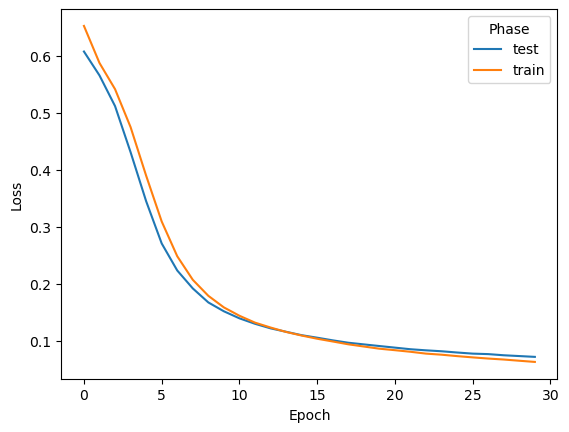

In [24]:
sns.lineplot(
    data=history_summary,
    x='Epoch',
    y='Loss',
    hue='Phase'
)

<Axes: xlabel='Epoch', ylabel='Accuracy'>

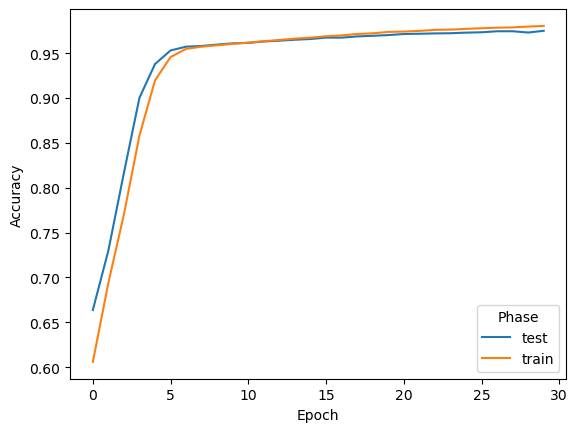

In [25]:
sns.lineplot(
    data=history_summary,
    x='Epoch',
    y='Accuracy',
    hue='Phase'
)

<Axes: xlabel='Epoch', ylabel='Macro-F1 Score'>

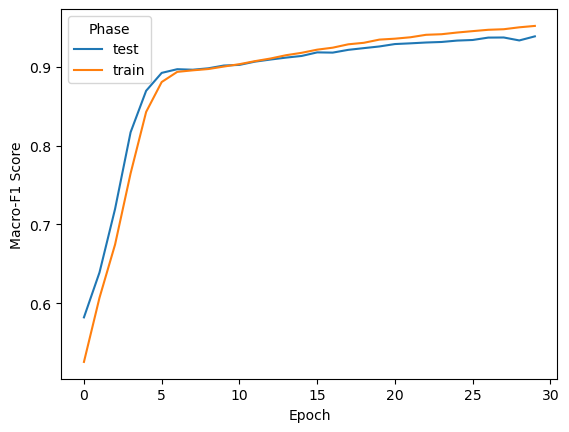

In [26]:
sns.lineplot(
    data=history_summary,
    x='Epoch',
    y='Macro-F1 Score',
    hue='Phase'
)

# Evaluation : More

In [27]:
def get_embeddings(
    x : Tensor,
    model : nn.Module,
    batch_size : int,
    device : str
) -> Tensor:
    
    model.to(device).eval()
    loader = DataLoader(dataset=TensorDataset(x), batch_size=batch_size, shuffle=False)
    
    Y = []
    
    with torch.inference_mode():

        for batch in tqdm(loader):
            batch = batch[0].to(device)
            embeddings = model.forward(batch)
            embeddings = embeddings.detach().cpu()
            Y.append(embeddings)

    Y = torch.cat(Y)

    return Y

In [28]:
y_test_hat = get_embeddings(x_test, model, batch_size=512, device=Config.device)

  0%|          | 0/2 [00:00<?, ?it/s]

# Competition Score

- Load Model Scores

In [30]:
target_scores = torch.load('../training/scores.pt',weights_only=False)
print(target_scores.size())

torch.Size([7186, 55])


- Load Real Model Checkpoint

In [31]:
target_articles = pd.read_csv('../training/test.csv')

- Get Sentence Bert Embeddings

In [32]:
target_articles_embeddings_sent = torch.from_numpy(
    sent_trans.encode(
        sentences=target_articles['abstract'].tolist(),
        batch_size=64,
        show_progress_bar=True,
        device='cuda',
        normalize_embeddings=True,
    )
)

Batches:   0%|          | 0/113 [00:00<?, ?it/s]

- Get Finetuned Model Predictions

In [33]:
target_articles_embeddings = get_embeddings(target_articles_embeddings_sent, model, batch_size=512, device=Config.device)

  0%|          | 0/15 [00:00<?, ?it/s]

- compute similarity to model score

In [34]:
def hard_jackidx_score(pred : Tensor, real : Tensor, th : float = 0.5) -> float:

    pred = pred >= th
    real = real >= th

    intersection = torch.min(torch.stack([pred,real], dim=0), dim=0).values.sum(-1)
    union = torch.max(torch.stack([pred,real], dim=0), dim=0).values.sum(-1)

    jacc_idx = intersection / (union + 1e-9)

    return jacc_idx.mean()

In [35]:
def soft_jackidx_score(pred : Tensor, real : Tensor) -> float:

    intersection = torch.min(torch.stack([pred,real], dim=0), dim=0).values.sum(-1)
    union = torch.max(torch.stack([pred,real], dim=0), dim=0).values.sum(-1)

    jacc_idx = intersection / (union + 1e-9)

    return jacc_idx.mean()

In [36]:
score_ = soft_jackidx_score(target_articles_embeddings, target_scores)
print(f"Similarity to target model : {100 * score_:.2f}%")

Similarity to target model : 65.43%


- Save Checkpoint

In [37]:
conf = asdict(config)
conf['hidden_act'] = conf['hidden_act'].__name__
conf['out_act'] = conf['out_act'].__name__

In [38]:
checkpoint = {
    "config" : conf,
    "state_dict" : model.state_dict(),
}

In [39]:
torch.save(checkpoint, 'mlp_head_chkp.pt')